In [14]:
# التعامل مع البيانات
import numpy as np
import pandas as pd

# تقسيم البيانات
from sklearn.model_selection import train_test_split

# التقييس
from sklearn.preprocessing import MinMaxScaler

# الخوارزميات
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
#التحقق المتقاطع
from sklearn.model_selection import cross_val_score
# التقييم
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import VotingClassifier


# الرسم البياني
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#step1:upload csv file
!gdown --id 1dvoO0RwoHVRtdXGIAwFqC_ls2bbsasEz
df = pd.read_csv('digit_rf -3.csv')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1dvoO0RwoHVRtdXGIAwFqC_ls2bbsasEz
To: /content/digit_rf -3.csv
100% 76.8M/76.8M [00:03<00:00, 21.1MB/s]


In [3]:
# المخرجات (الرقم الصحيح)
y = df['label']

# المدخلات (البكسلات)
X = df.drop('label', axis=1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (42000, 784)
Shape of y: (42000,)


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (29400, 784)
Testing size: (6300, 784)


In [5]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [6]:
log_model = LogisticRegression(max_iter=1000)
scores = cross_val_score(log_model, X_train_scaled, y_train, cv=5)

In [7]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(512,256,128),
    activation='relu',
    max_iter=100,
    random_state=42
)

In [8]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

In [21]:
# تدريب النماذج بشكل منفصل
log_model.fit(X_train_scaled, y_train)
mlp_model.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)

# التنبؤ
y_pred_log = log_model.predict(X_test_scaled)
y_pred_mlp = mlp_model.predict(X_test_scaled)
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_ensemble = ensemble_model.predict(X_test_scaled)

Ensemble Accuracy: 0.9766666666666667


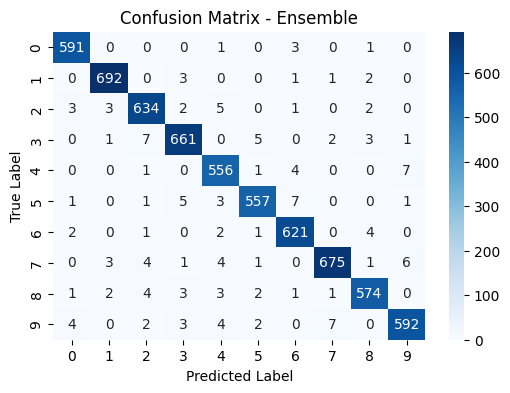

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       596
           1       0.99      0.99      0.99       699
           2       0.97      0.98      0.97       650
           3       0.97      0.97      0.97       680
           4       0.96      0.98      0.97       569
           5       0.98      0.97      0.97       575
           6       0.97      0.98      0.98       631
           7       0.98      0.97      0.98       695
           8       0.98      0.97      0.97       591
           9       0.98      0.96      0.97       614

    accuracy                           0.98      6300
   macro avg       0.98      0.98      0.98      6300
weighted avg       0.98      0.98      0.98      6300



In [22]:
# التنبؤ باستخدام Ensemble فقط
y_pred_ensemble = ensemble_model.predict(X_test_scaled)

# دقة النموذج
print("Ensemble Accuracy:", accuracy_score(y_test, y_pred_ensemble))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Ensemble")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_ensemble))

In [18]:
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('mlp', mlp_model),
        ('svm', svm_model)
    ],
    voting='hard'
)

ensemble_model.fit(X_train_scaled, y_train)

y_pred = ensemble_model.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_pred)

print("Final Model Accuracy:", final_accuracy)

Final Model Accuracy: 0.9766666666666667
